In [5]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
    drifters_structure,
)
from diagnosis import (
    dataset_coloc_combs,
    generate_0_15m_coloc_dataframe,
    sel_structure,
    compute_variance_groupby,
    compute_variance,
    prepared_alti,
    put_fig_letter,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U, structure

depthcolor = {0: "navy", 15: "green", 50: "yellowgreen", 100: "yellow"}

In [6]:
dt = 12
alti_product_key = "swot2km"
drifter_preprocess = ""
drifter_preprocess_param = ""
from diagnosis import define_coloc_source

colocs_sources = define_coloc_source(
    "12h", drifter_preprocess, drifter_preprocess_param
)

In [7]:
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)


comb_list = [base_dic]
l = [
    "L3-2km",
]
ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth == 0, drop=True)], dim="row_number")
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed


In [8]:
df = DS.isel(id_comb=0).to_dataframe()

In [9]:
c = "BioSWOT-Med"

In [10]:
d = sel_structure(df, **structure[c])

In [ ]:
dr = d.drifter_id.unique()
dr

/dev/shm/pbs.4183496.datarmor0/ipykernel_36376/1643932190.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2, figsize = (10, 5))


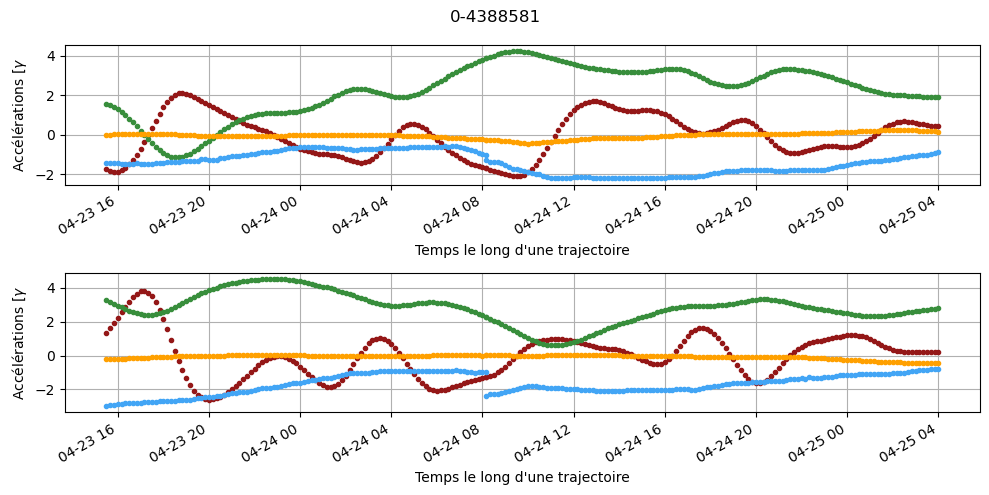

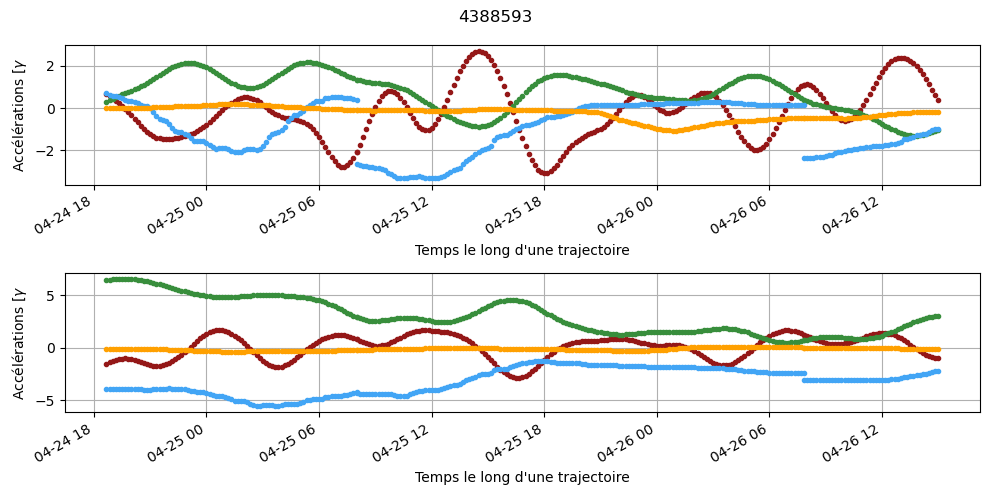

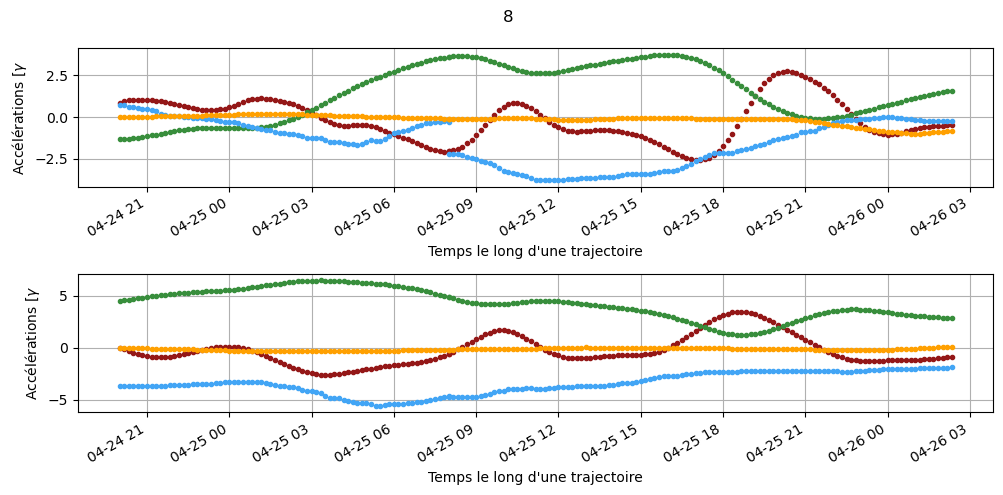

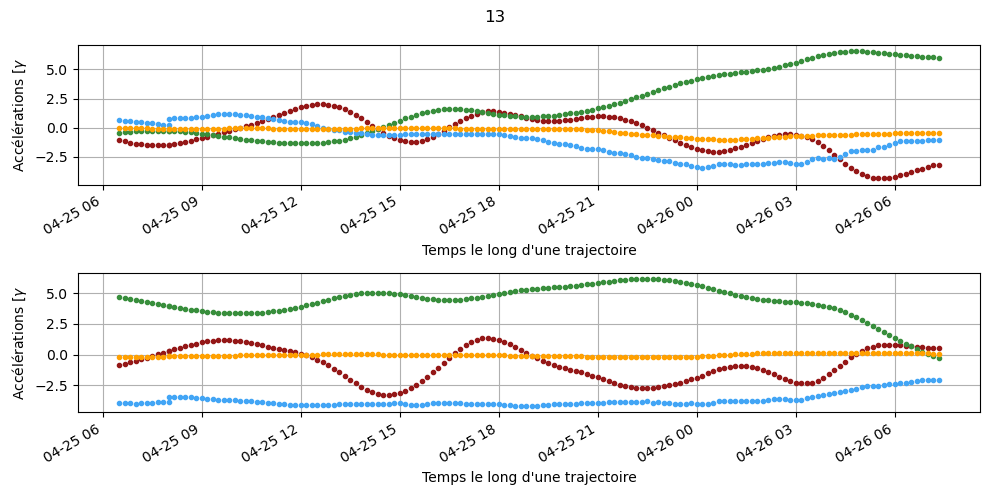

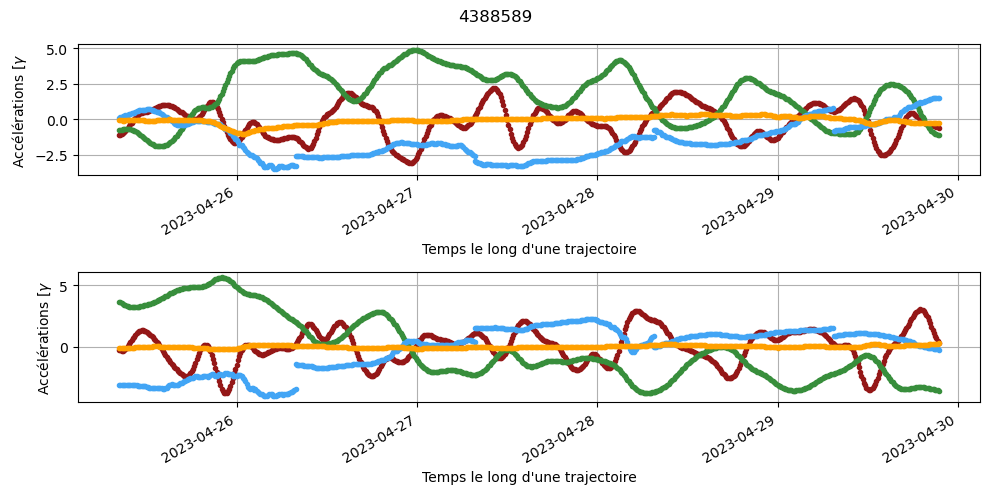

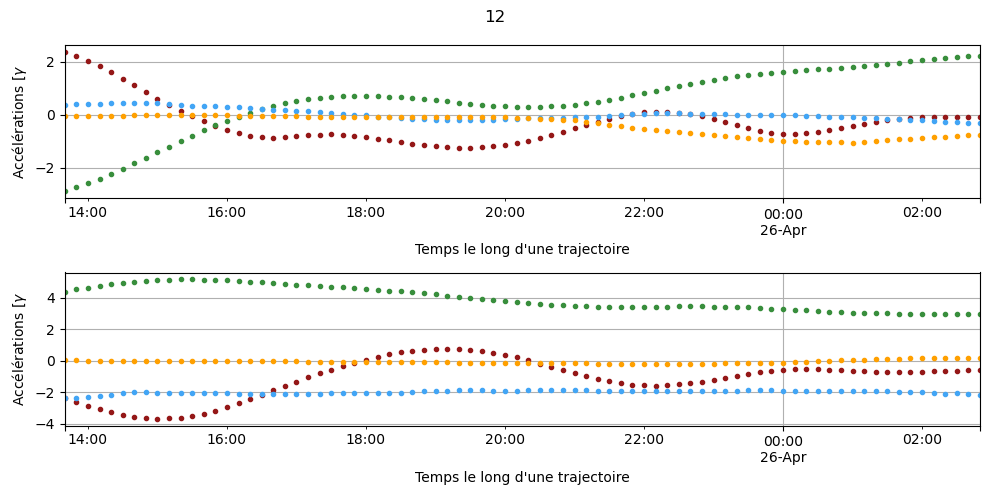

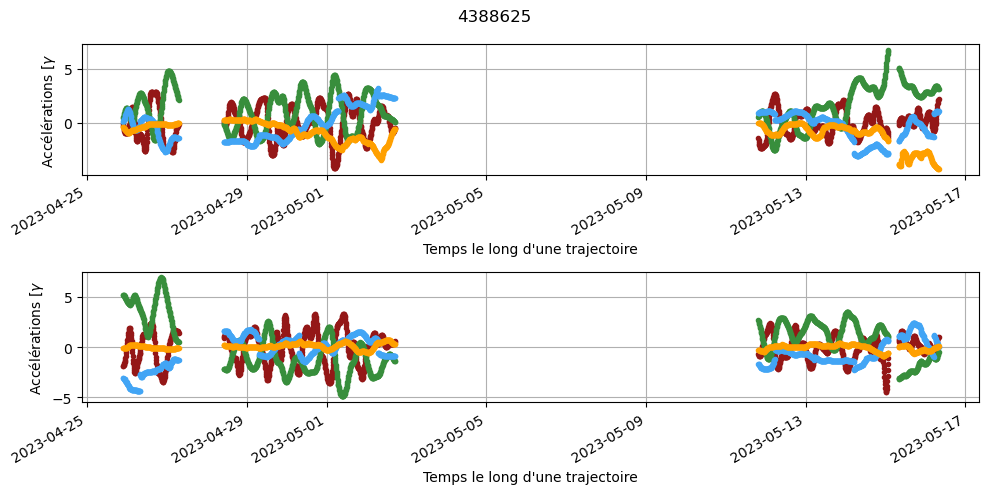

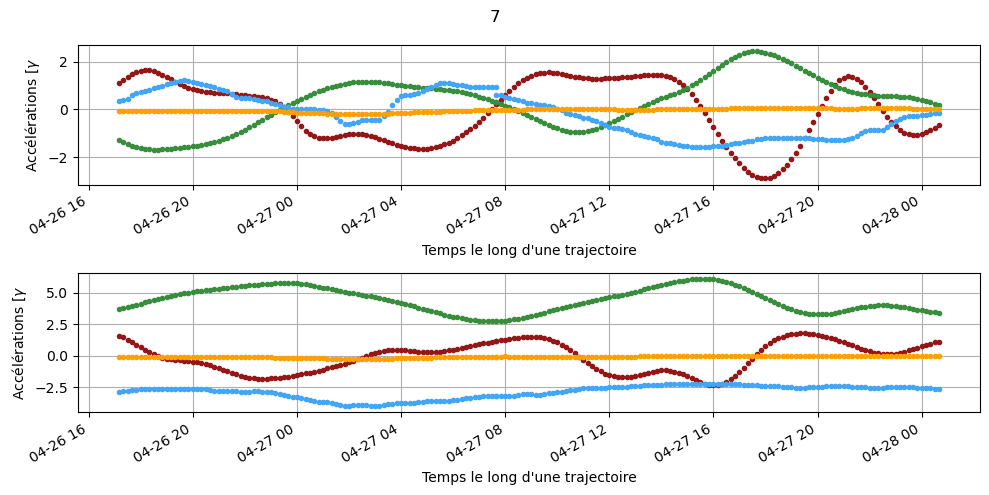

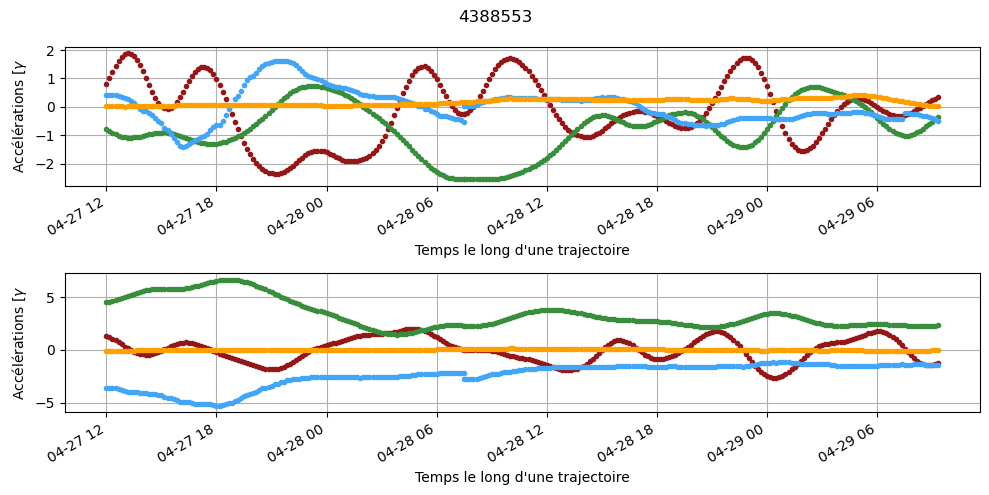

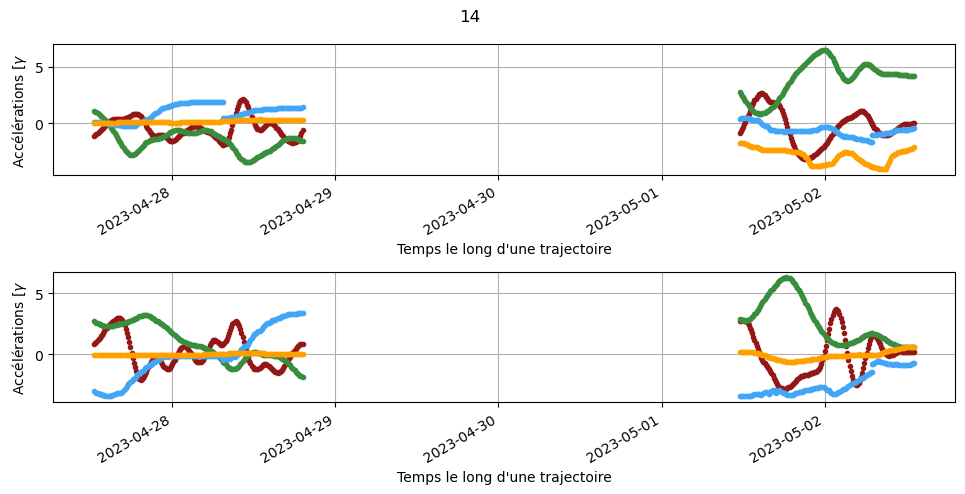

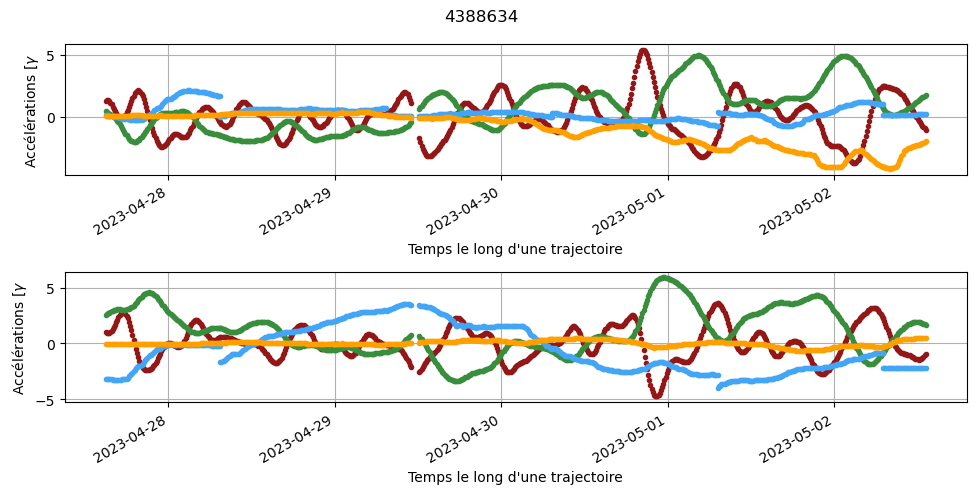

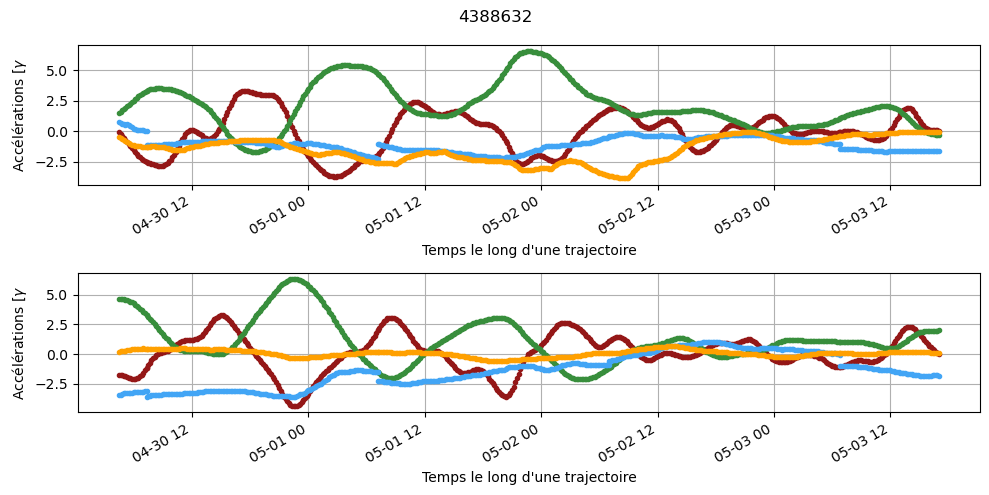

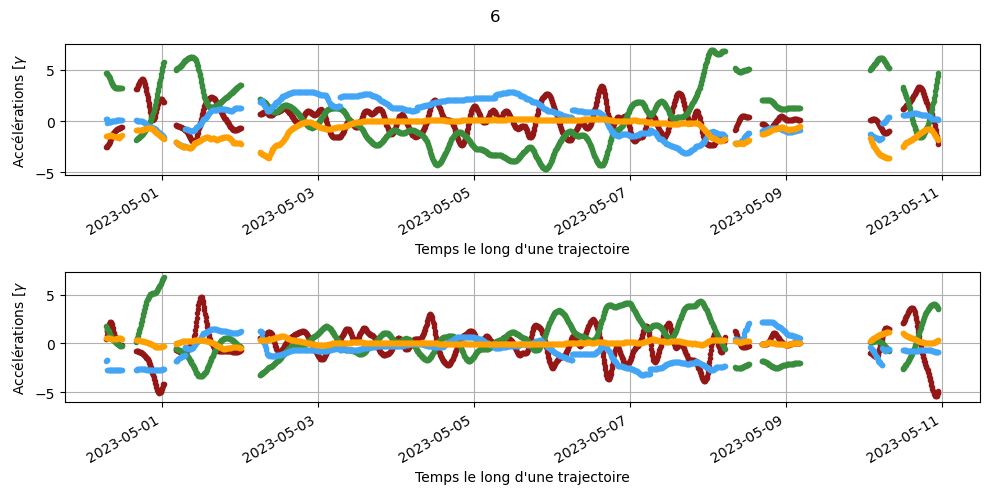

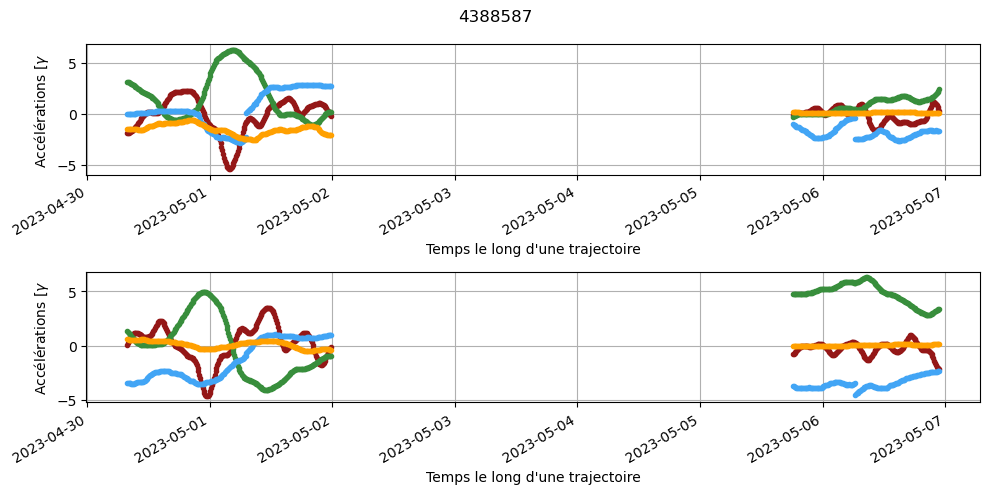

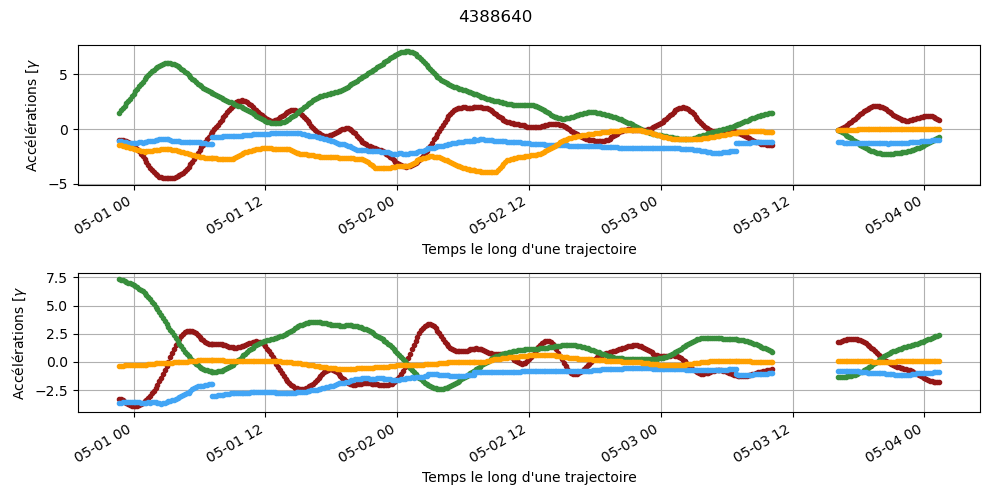

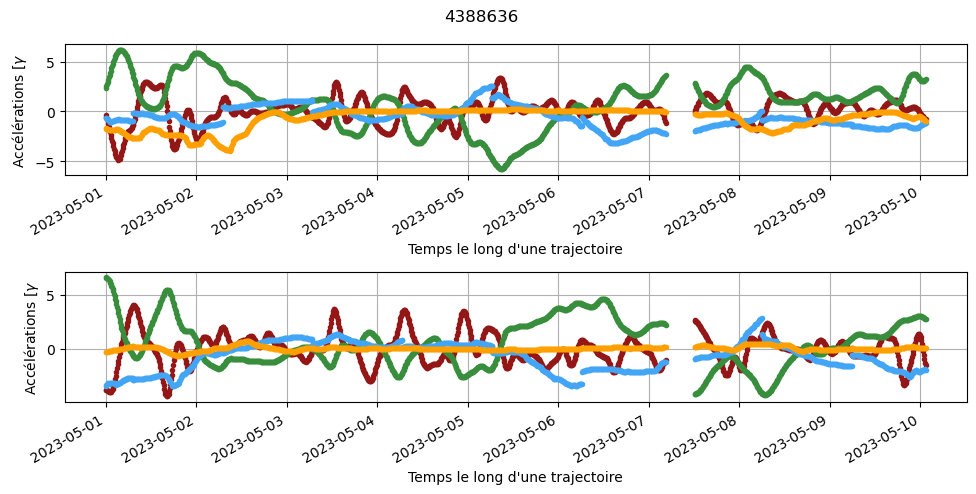

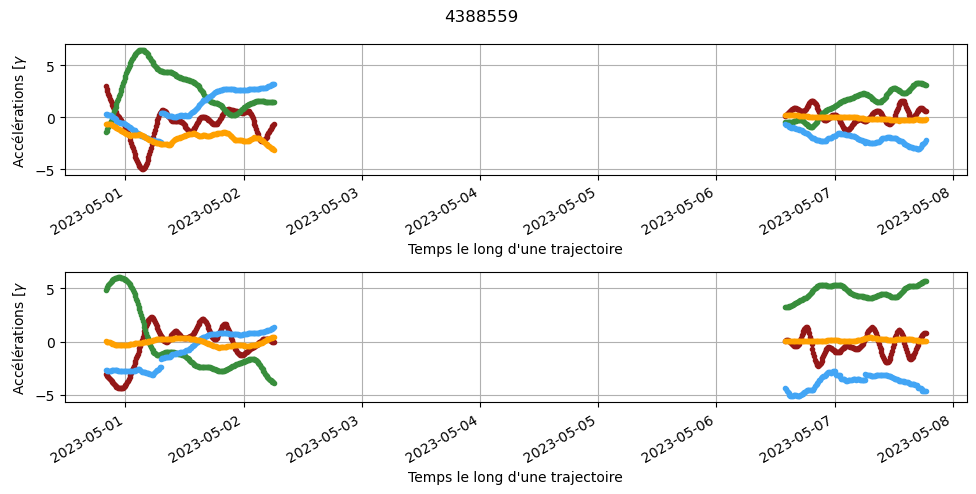

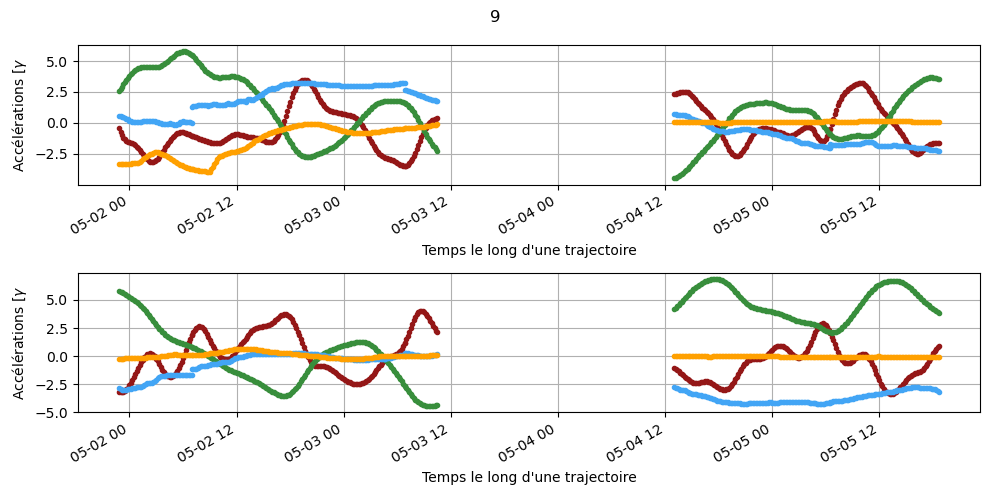

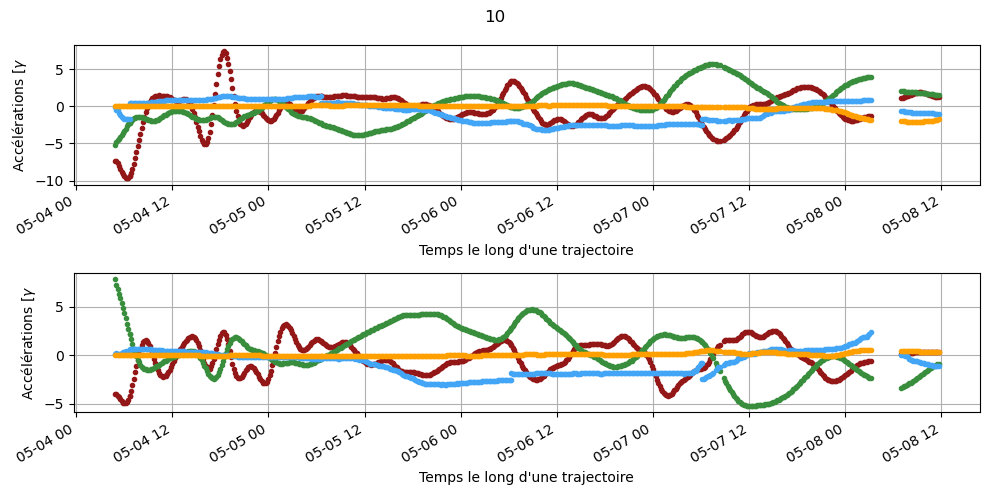

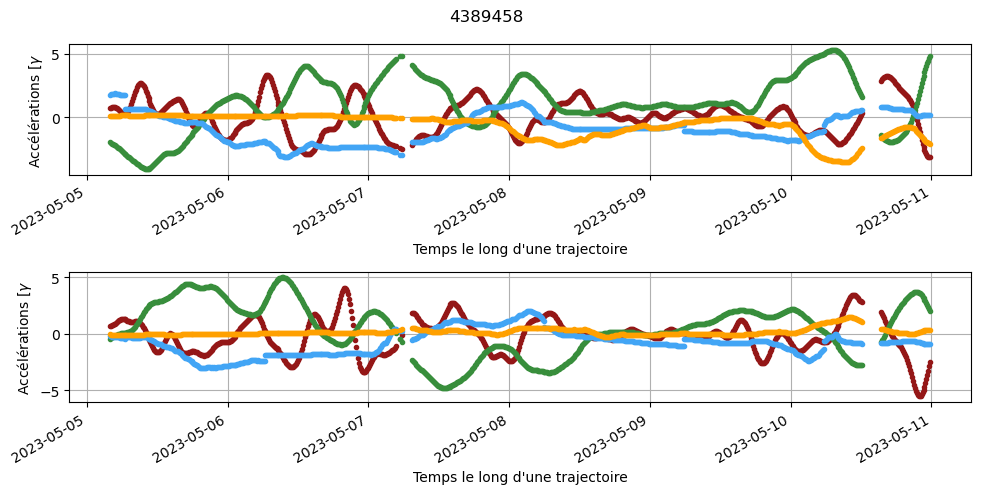

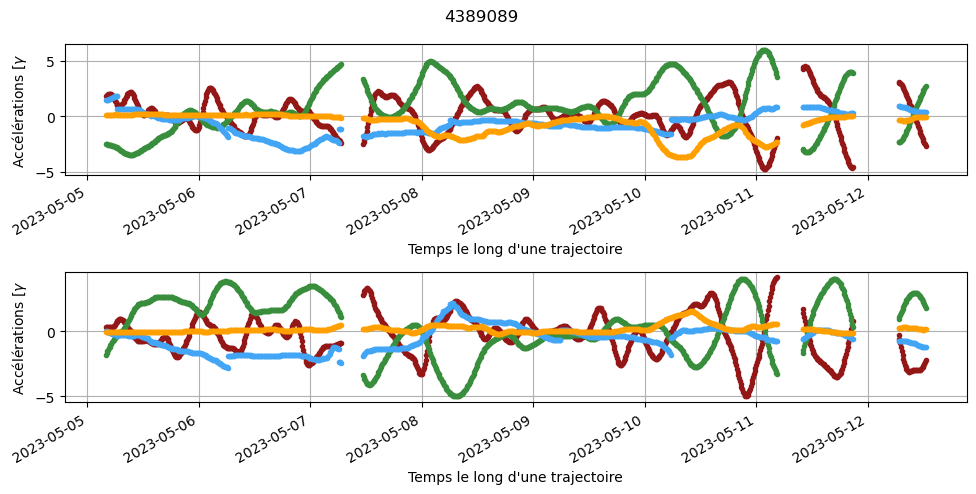

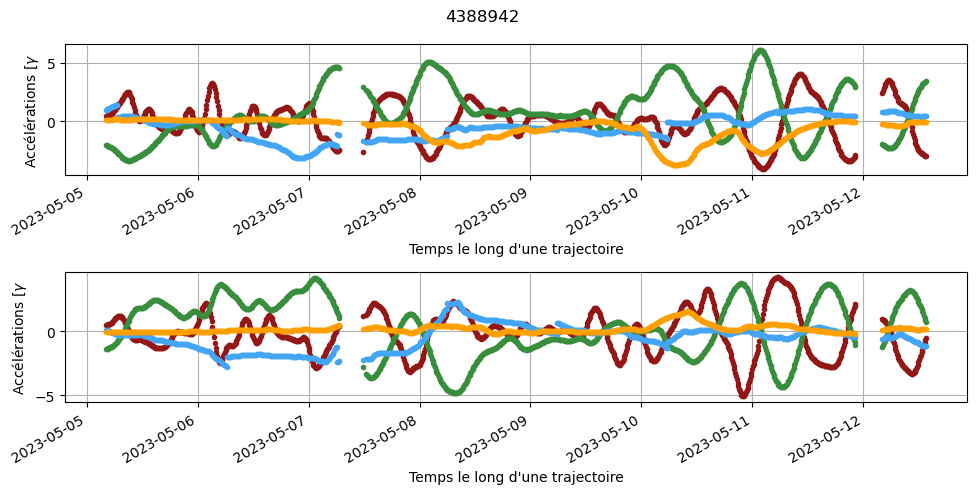

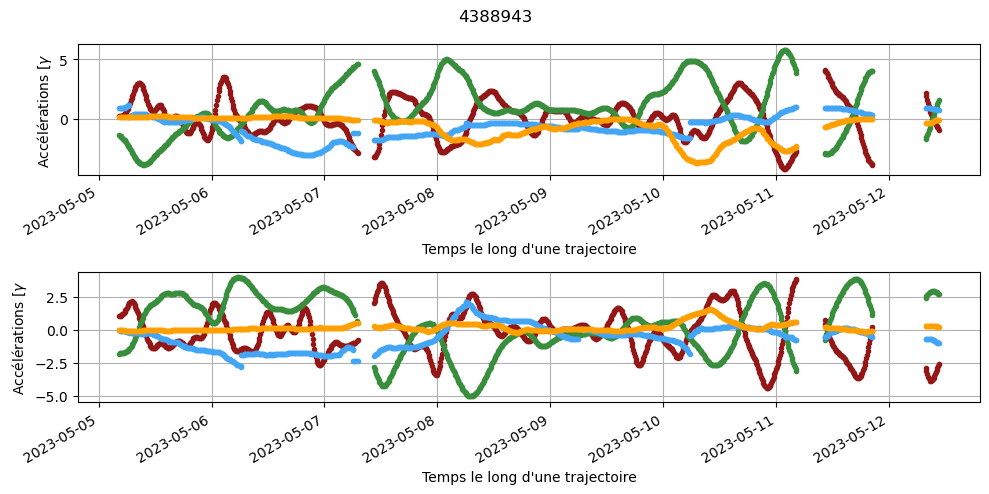

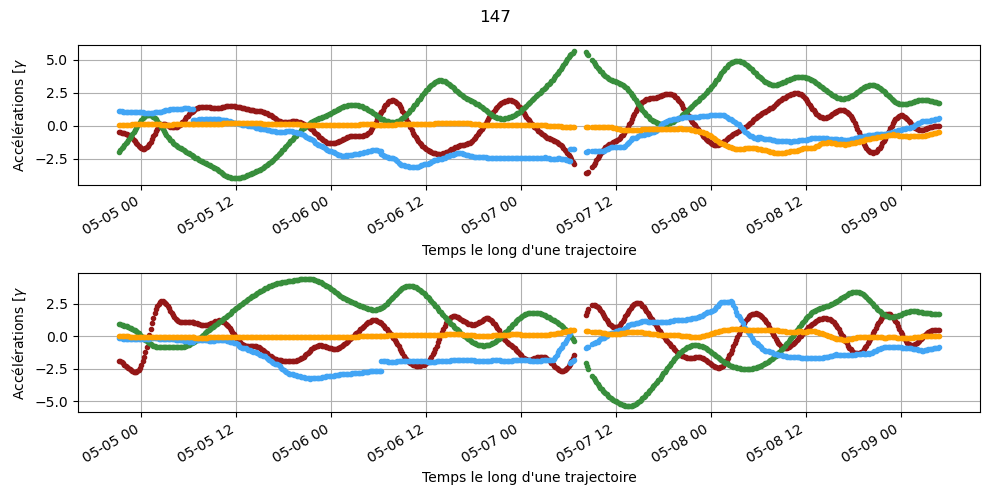

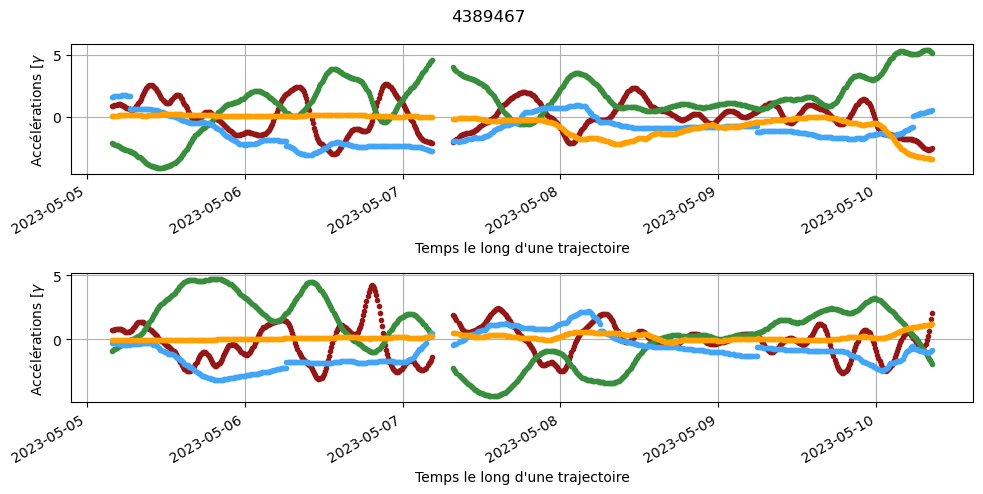

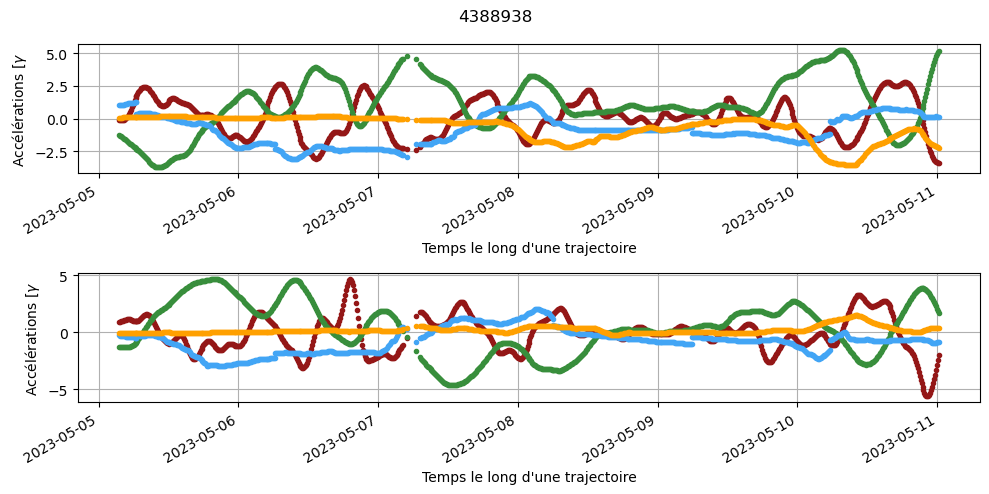

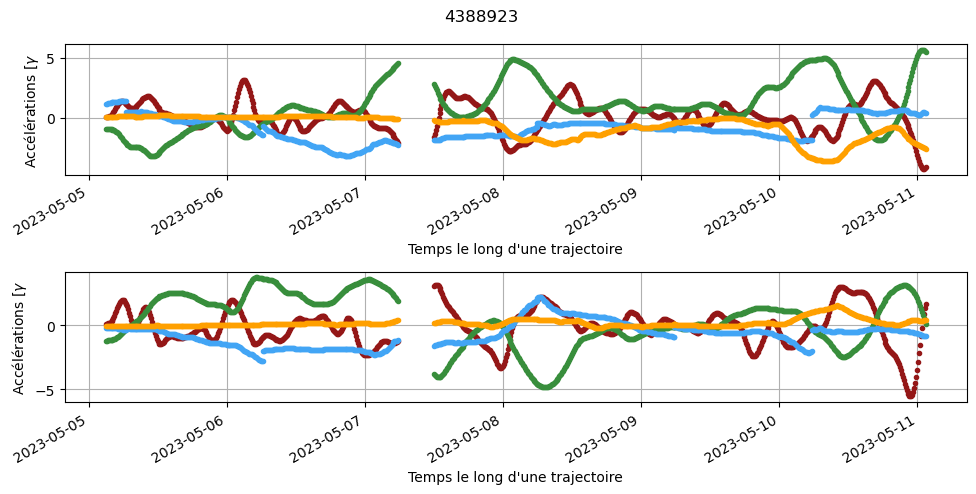

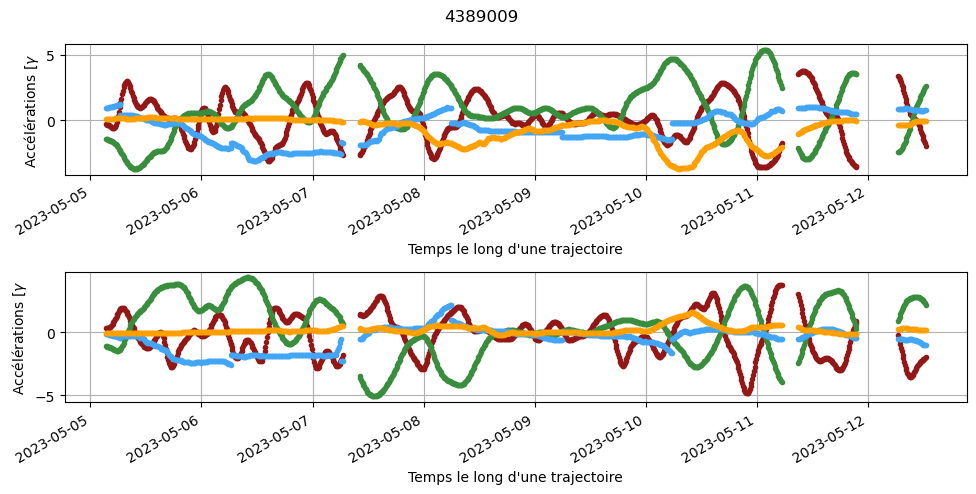

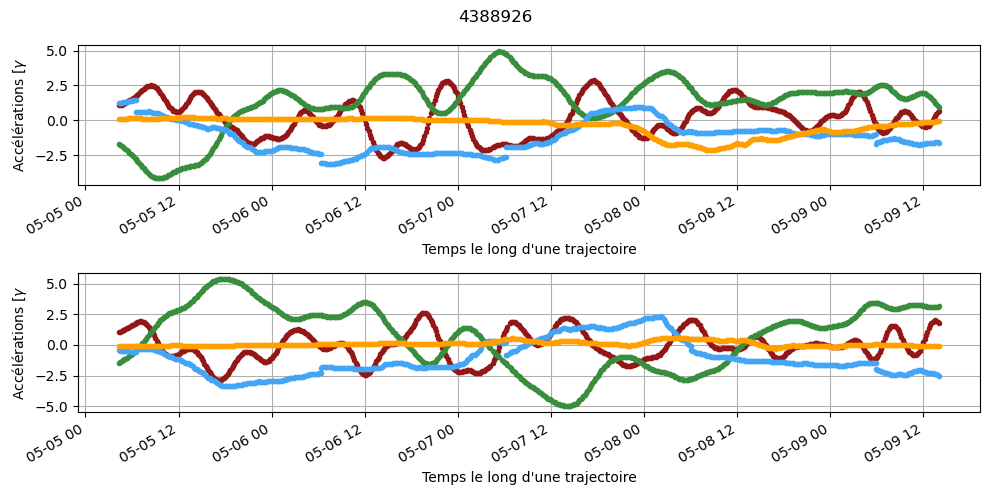

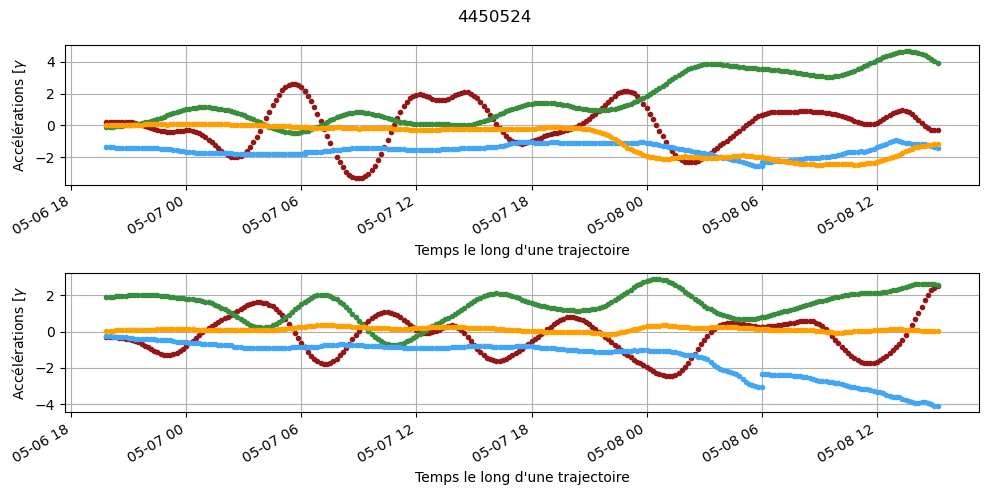

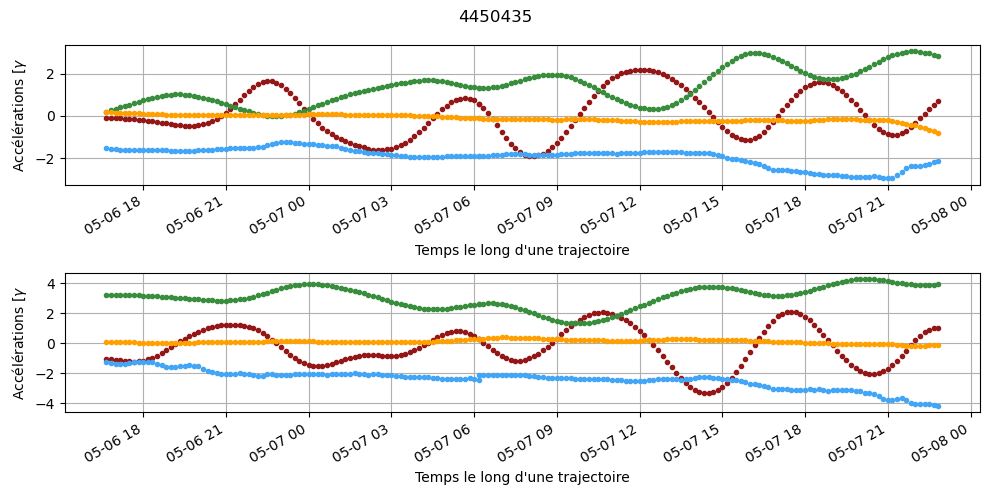

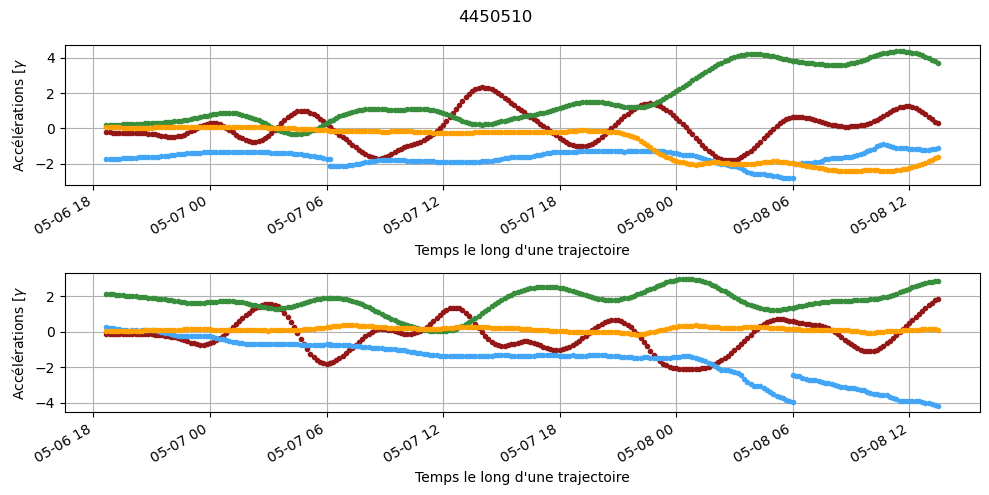

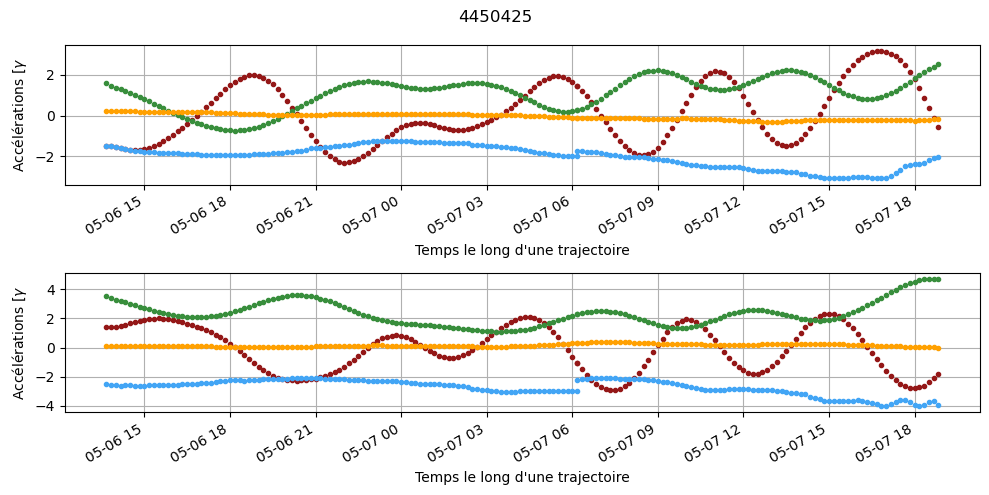

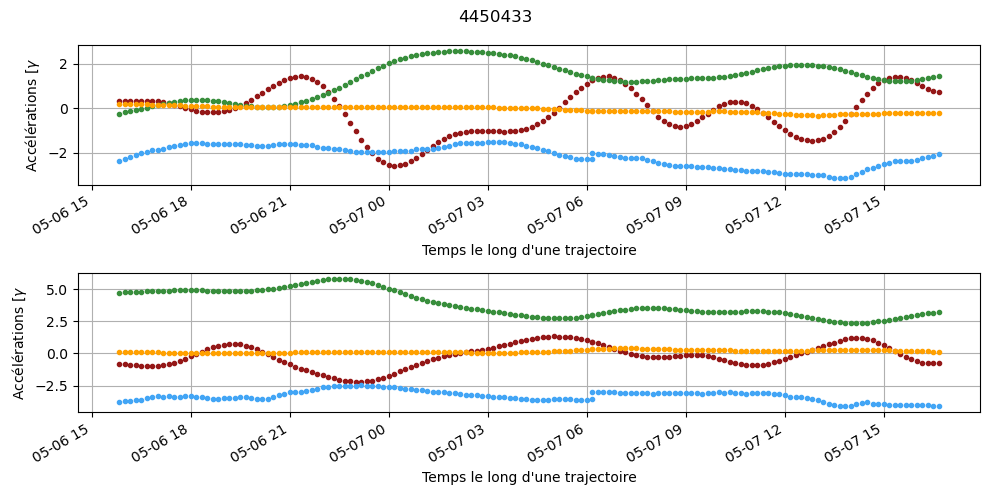

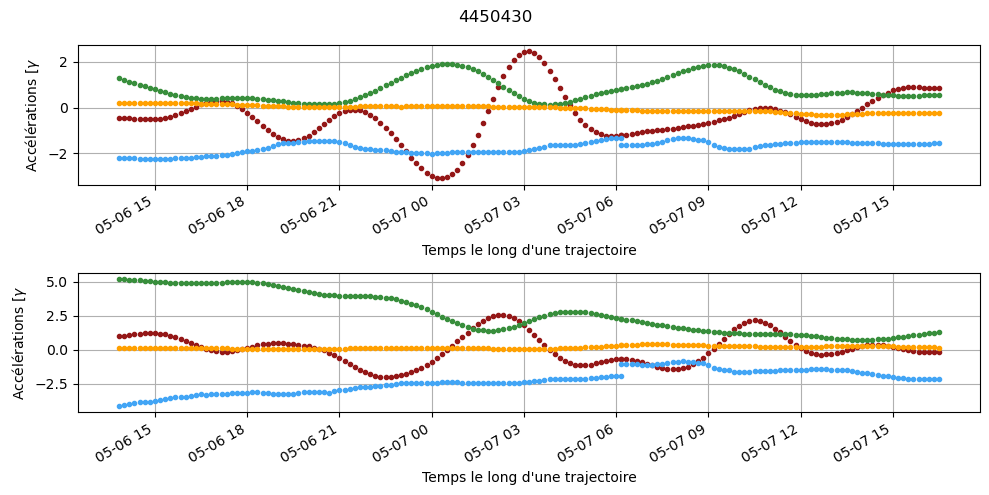

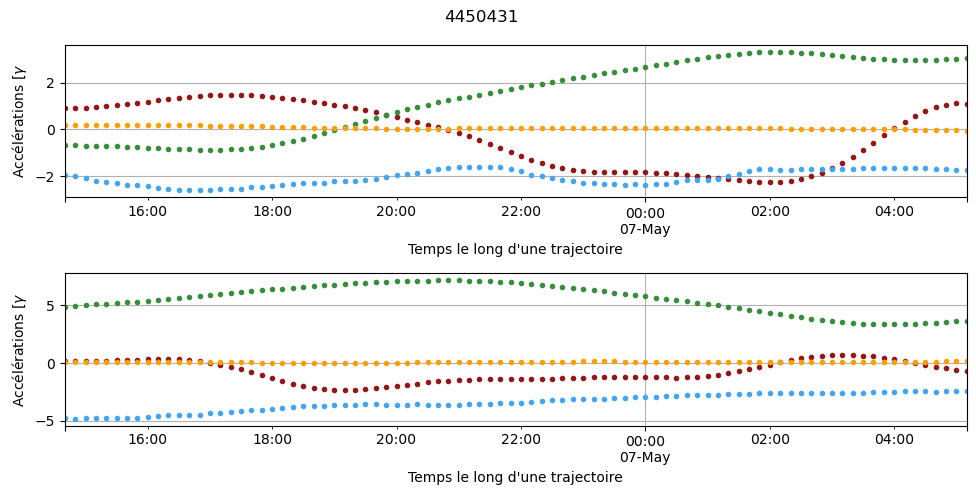

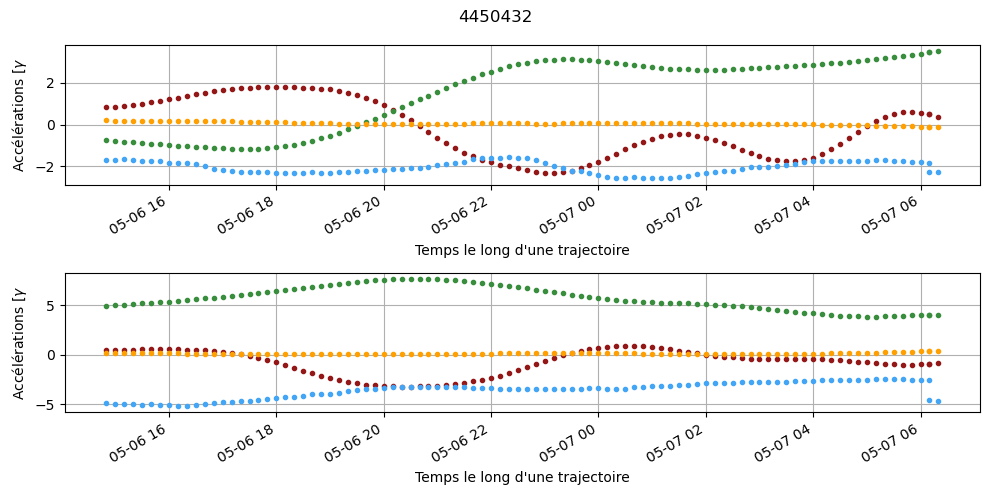

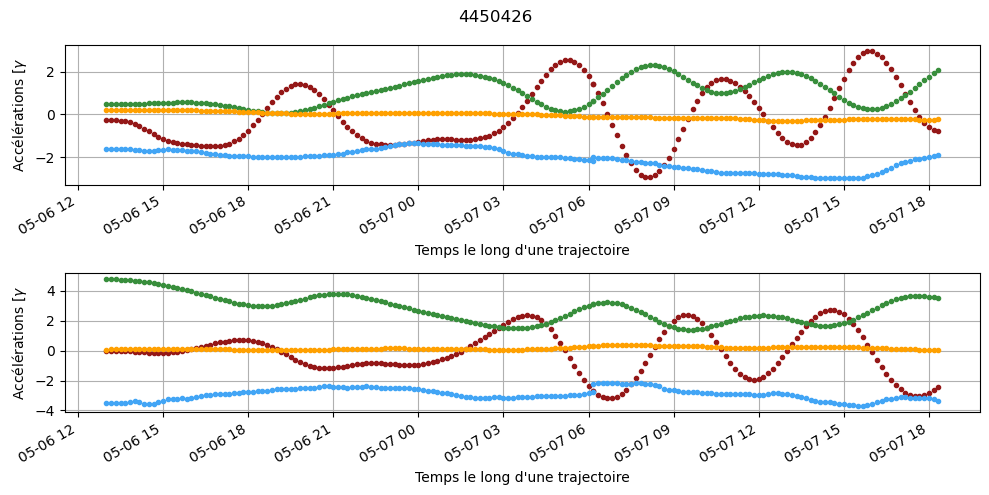

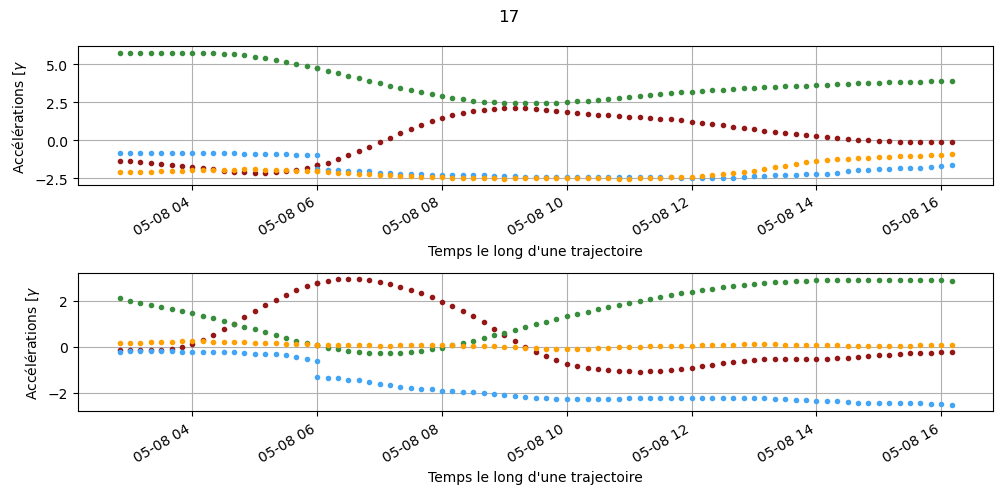

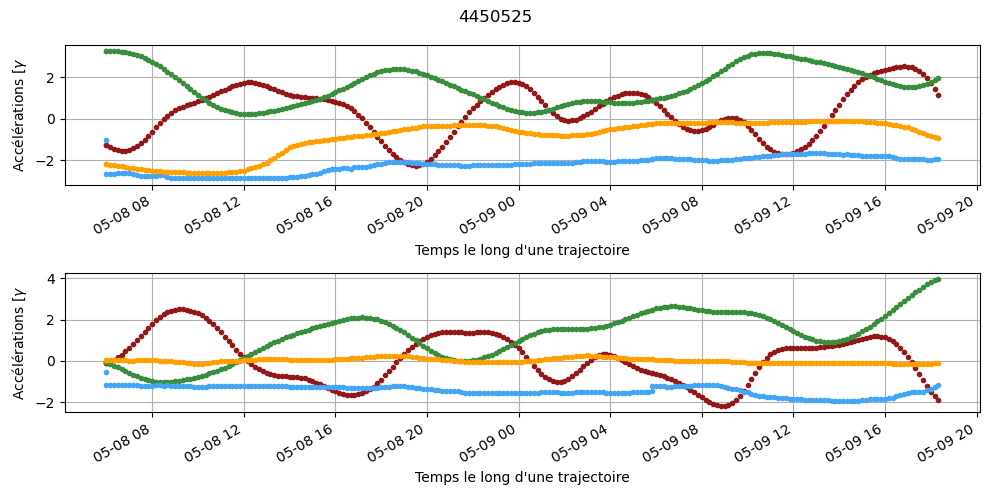

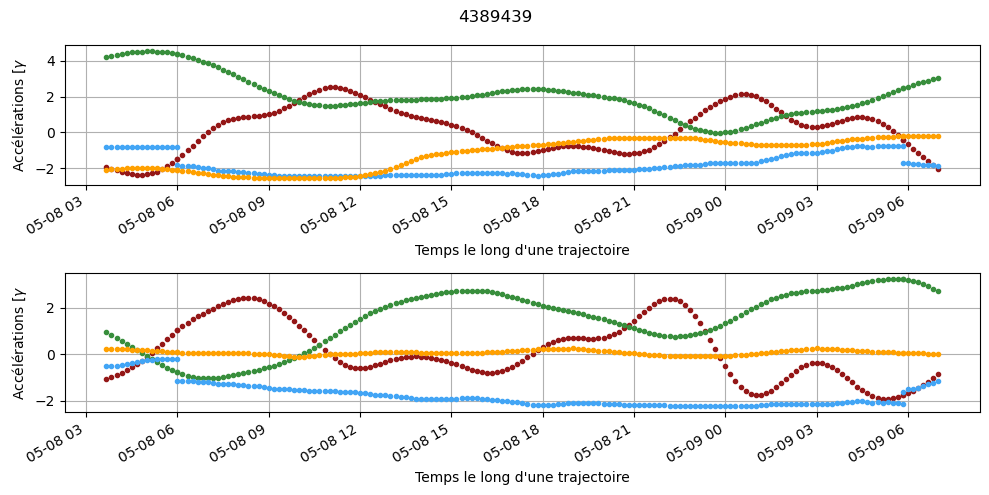

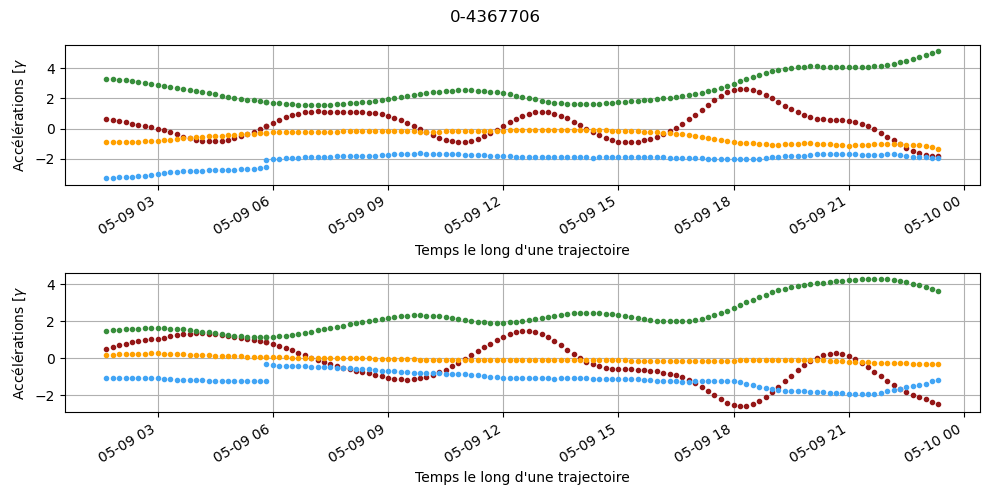

In [68]:
for dr_ in dr:
    d_ = d[d.drifter_id == dr_].set_index("datetime")
    fig, axs = plt.subplots(2, figsize=(10, 5))
    for v in ["acc", "cor", "ggd", "wd"]:
        (d_[v + "e"] / U).plot(ax=axs[0], c=c0[v], ls="", marker=".")
        (d_[v + "n"] / U).plot(ax=axs[1], c=c0[v], ls="", marker=".")
    for ax in axs:
        ax.grid()
        ax.set_xlabel("Temps le long d'une trajectoire")
        ax.set_ylabel(r"Accélérations [$\gamma$")

    fig.suptitle(dr_)
    fig.tight_layout()

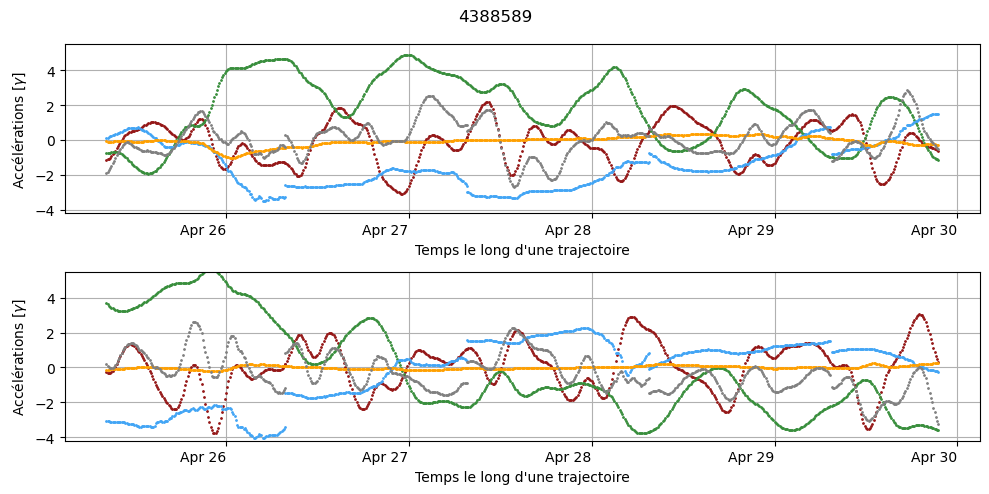

In [112]:
dr_ = "4388589"
d_ = d[d.drifter_id == dr_].set_index("datetime")
fig, axs = plt.subplots(2, figsize=(10, 5), frameon=False)
for v in ["acc", "cor", "ggd", "wd", "sum"]:
    alpha = 1
    (d_[v + "e"] / U).plot(
        ax=axs[0], c=c0[v], alpha=alpha, ls="", marker="o", markersize=1
    )
    (d_[v + "n"] / U).plot(
        ax=axs[1], c=c0[v], alpha=alpha, ls="", marker="o", markersize=1
    )
for ax in axs:
    ax.grid()
    ax.set_xlabel("Temps le long d'une trajectoire")
    ax.set_ylabel(r"Accélérations [$\gamma$]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(-4.2, 5.5)
fig.suptitle(dr_)
fig.tight_layout()

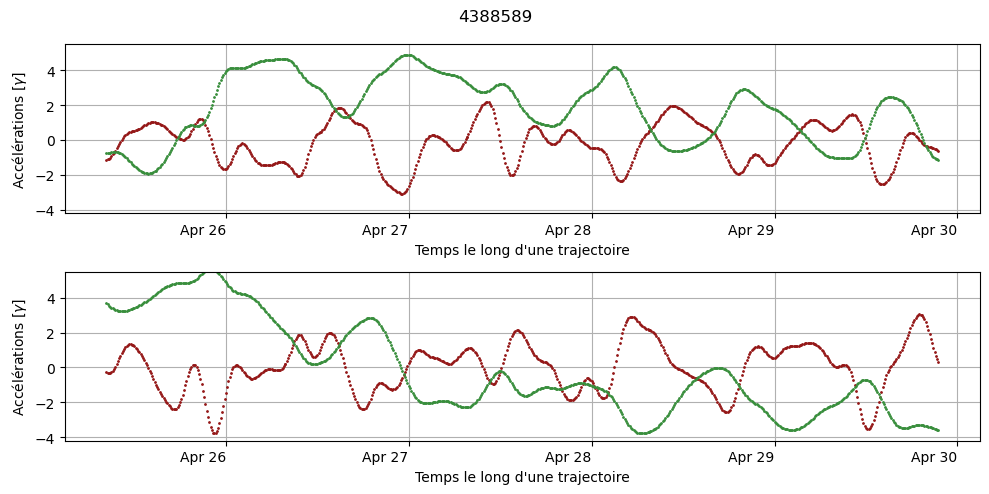

In [113]:
dr_ = "4388589"
d_ = d[d.drifter_id == dr_].set_index("datetime")
fig, axs = plt.subplots(2, figsize=(10, 5), frameon=False)
for v in ["acc", "cor"]:  # , 'ggd', 'wd'] :
    if v in ["acc", "cor"]:
        alpha = 1
    # else : alpha=0.2
    (d_[v + "e"] / U).plot(
        ax=axs[0], c=c0[v], alpha=alpha, ls="", marker="o", markersize=1
    )
    (d_[v + "n"] / U).plot(
        ax=axs[1], c=c0[v], alpha=alpha, ls="", marker="o", markersize=1
    )
for ax in axs:
    ax.grid()
    ax.set_xlabel("Temps le long d'une trajectoire")
    ax.set_ylabel(r"Accélérations [$\gamma$]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(-4.2, 5.5)
fig.suptitle(dr_)
fig.tight_layout()

In [61]:
c0["sum"] = "grey"

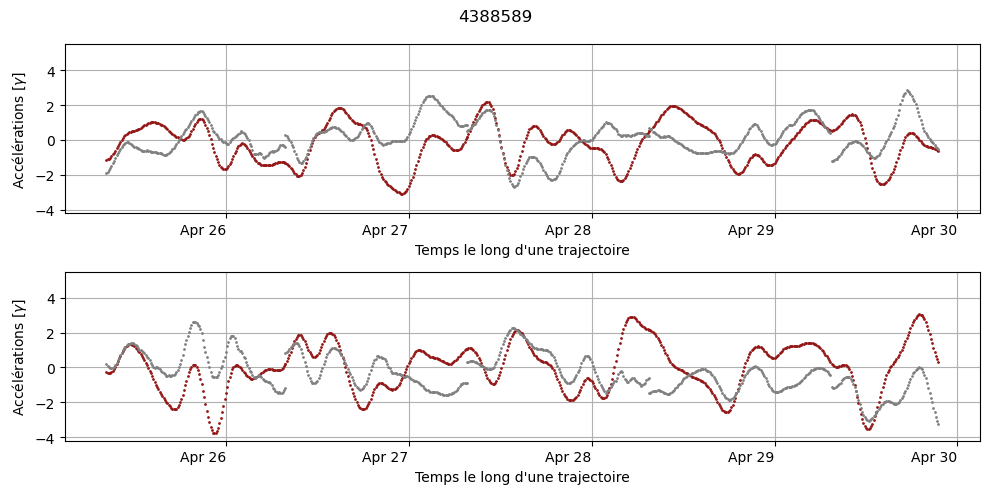

In [114]:
dr_ = "4388589"
d_ = d[d.drifter_id == dr_].set_index("datetime")
fig, axs = plt.subplots(2, figsize=(10, 5), frameon=False)
for v in ["acc", "cor", "ggd", "wd", "sum"]:
    if v in ["acc", "sum"]:
        alpha = 1
    else:
        alpha = 0
    (d_[v + "e"] / U).plot(
        ax=axs[0], c=c0[v], alpha=alpha, ls="", marker="o", markersize=1
    )
    (d_[v + "n"] / U).plot(
        ax=axs[1], c=c0[v], alpha=alpha, ls="", marker="o", markersize=1
    )
for ax in axs:
    ax.grid()
    ax.set_xlabel("Temps le long d'une trajectoire")
    ax.set_ylabel(r"Accélérations [$\gamma$]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(-4.2, 5.5)
fig.suptitle(dr_)
fig.tight_layout()

In [192]:
v = (d_["acce"] + d_["core"] + d_["wde"]).to_xarray() / U
vd = v.isel(datetime=slice(None, None, 25))
vd = vd.interp(datetime=v.datetime)

In [195]:
noise = xr.DataArray(
    np.random.normal(loc=0.0, scale=0.5, size=v.shape),  # bruit gaussien
    dims=v.dims,
    coords=v.coords,
)
vn = -v + noise

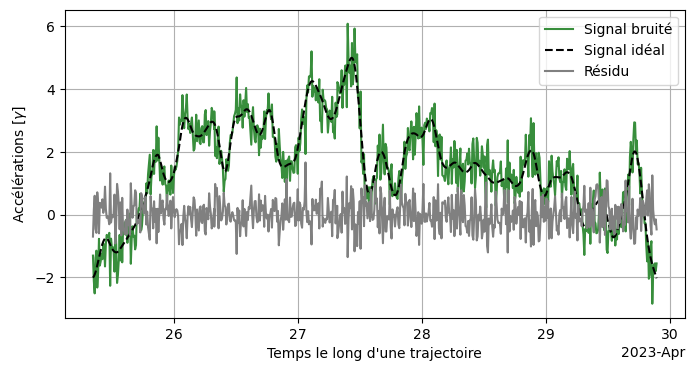

In [197]:
fig, ax = plt.subplots(figsize=(8, 4))

(-vn).plot(ax=ax, c=c0["cor"], label="Signal bruité")
v.plot(ax=ax, c="k", ls="--", label="Signal idéal")
(vn + v).plot(c="grey", label="Résidu")
ax.grid()
ax.set_xlabel("Temps le long d'une trajectoire")
ax.set_ylabel(r"Accélérations [$\gamma$]")
ax.legend()

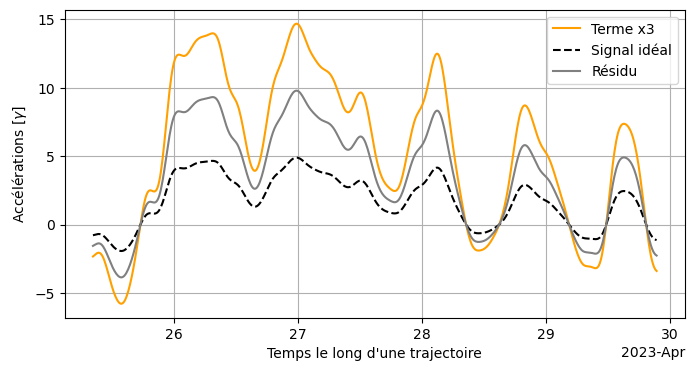

In [205]:
v = (d_["core"]).to_xarray() / U
vw = 3 * v
fig, ax = plt.subplots(figsize=(8, 4))

vw.plot(ax=ax, c=c0["wd"], label="Terme x3")
v.plot(ax=ax, c="k", ls="--", label="Signal idéal")
(vw - v).plot(c="grey", label="Résidu")

ax.grid()
ax.set_xlabel("Temps le long d'une trajectoire")
ax.set_ylabel(r"Accélérations [$\gamma$]")
ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


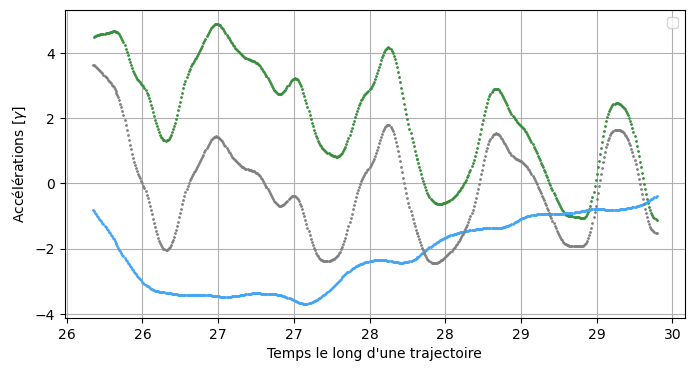

In [54]:
dr_ = "4388589"
d_ = d[d.drifter_id == dr_].set_index("datetime")

fig, ax = plt.subplots(figsize=(8, 4))
a = (-d_["core"]).to_xarray().rolling(datetime=120).mean() / U
b = (d_["core"] / U).to_xarray()
# b = b.interp(datetime=a.datetime)
b.isel(datetime=slice(120, None)).plot(
    ax=ax, c=c0["cor"], ls="", marker="o", markersize=1
)
a.plot(ax=ax, c=c0["ggd"], ls="", marker="o", markersize=1)
(a + b).plot(ax=ax, c="grey", ls="", marker="o", markersize=1)
ax.grid()
ax.set_xlabel("Temps le long d'une trajectoire")
ax.set_ylabel(r"Accélérations [$\gamma$]")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
plt.setp(ax.get_xticklabels(), rotation=0)
ax.legend()

In [37]:
a

<xarray.DataArray 'core' (datetime: 540)> Size: 4kB
array([-0.81459084, -0.85839026, -0.90223711, -0.94608743, -0.9899139 ,
       -1.03370722, -1.07747677, -1.12125028, -1.16507246, -1.20900269,
       -1.25311189, -1.2974786 , -1.34218477, -1.38731154, -1.43293546,
       -1.47912489, -1.52593636, -1.5734107 , -1.6215695 , -1.67041256,
       -1.71991695, -1.77003733, -1.82070679, -1.87197005, -1.92366335,
       -1.97567416, -2.02787493, -2.08012688, -2.13228456, -2.18420059,
       -2.2357301 , -2.28673493, -2.33708778, -2.38667641, -2.43540717,
       -2.48320686, -2.53002279, -2.57582116, -2.62058449, -2.6643082 ,
       -2.70699628, -2.74865627, -2.78929407, -2.82890883, -2.86748872,
       -2.90500731, -2.94142095, -2.97666751, -3.01066667, -3.04332186,
       -3.07452387, -3.10415585, -3.1320996 , -3.15824292, -3.18248743,
       -3.20475649, -3.22500239, -3.24321188, -3.25940979, -3.27366049,
       -3.28606695, -3.2967676 , -3.30593086, -3.31374806, -3.32042537,
       -3.32617656, -3.33121333, -3.33574052, -3.33995149, -3.34402109,
       -3.34809758, -3.35230072, -3.35672128, -3.3614159 , -3.36640813,
       -3.3716897 , -3.37722288, -3.38294389, -3.38876724, -3.39459115,
       -3.40030366, -3.40578891, -3.41093297, -3.41562916, -3.41978277,
       -3.42331497, -3.42616605, -3.42829762, -3.42969387, -3.43036182,
       -3.43033069, -3.42965059, -3.42839086, -3.42663824, -3.42449471,
       -3.42207489, -3.41950251, -3.41690614, -3.41441453, -3.41215168,
...
       -0.93266089, -0.93262256, -0.93253471, -0.93234368, -0.93199826,
       -0.93145187, -0.9306647 , -0.92960586, -0.92825519, -0.9266043 ,
       -0.92465687, -0.92242776, -0.91994104, -0.91722685, -0.91431763,
       -0.91124409, -0.90803118, -0.90469468, -0.90123892, -0.89765606,
       -0.89392701, -0.89002363, -0.88591206, -0.88155654, -0.8769237 ,
       -0.87198669, -0.86672895, -0.86114741, -0.85525549, -0.84908551,
       -0.84269141, -0.83614539, -0.82953928, -0.82298391, -0.81660118,
       -0.81051984, -0.80486955, -0.79977448, -0.79534682, -0.79168095,
       -0.78884857, -0.78689476, -0.78583534, -0.78565544, -0.78630939,
       -0.78772211, -0.78979222, -0.79239647, -0.7953949 , -0.79863653,
       -0.8019653 , -0.80522624, -0.80827127, -0.81096446, -0.81318667,
       -0.81483978, -0.81585026, -0.81617158, -0.81578521, -0.81469983,
       -0.81294879, -0.81058569, -0.80767868, -0.80430406, -0.80053988,
       -0.79646028, -0.79213085, -0.78760534, -0.78292361, -0.77811054,
       -0.77317554, -0.76811261, -0.76290089, -0.75750516, -0.75187663,
       -0.74595392, -0.73966482, -0.73292844, -0.72565759, -0.71776118,
       -0.70914683, -0.699724  , -0.68940739, -0.67812054, -0.66579982,
       -0.65239881, -0.63789289, -0.62228346, -0.60560128, -0.58790791,
       -0.56929478, -0.54987974, -0.52980158, -0.50921341, -0.48827558,
       -0.46714867, -0.44598709, -0.42493332, -0.40411337, -0.38363336])
Coordinates:
  * datetime  (datetime) datetime64[ns] 4kB 2023-04-26T04:10:00 ... 2023-04-2...

In [18]:
(-d_["core"]).to_xarray().rolling(datetime=40).mean()

<xarray.DataArray 'core' (datetime: 659)> Size: 5kB
array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,  1.27715199e-05,
        1.29962781e-05,  1.32081382e-05,  1.34057192e-05,  1.35872953e-05,
        1.37507568e-05,  1.38935951e-05,  1.40129298e-05,  1.41055761e-05,
        1.41681412e-05,  1.41971328e-05,  1.41890775e-05,  1.41406474e-05,
        1.40487937e-05,  1.39108882e-05,  1.37248700e-05,  1.34893914e-05,
        1.32039481e-05,  1.28689815e-05,  1.24859280e-05,  1.20571971e-05,
        1.15860721e-05,  1.10765467e-05,  1.05331159e-05,  9.96054369e-06,
        9.36363164e-06,  8.74700843e-06,  8.11494365e-06,  7.47118993e-06,
        6.81889807e-06,  6.16042860e-06,  5.49737681e-06,  4.83062509e-06,
        4.16023539e-06,  3.48551071e-06,  2.80505535e-06,  2.11686198e-06,
        1.41841331e-06,  7.06800248e-07, -2.11310024e-08, -7.68600039e-07,
...
        1.90609440e-06,  2.43363122e-06,  2.94561386e-06,  3.44230875e-06,
        3.92388675e-06,  4.39028059e-06,  4.84105345e-06,  5.27527352e-06,
        5.69139916e-06,  6.08716795e-06,  6.45967473e-06,  6.80533084e-06,
        7.11989021e-06,  7.39870236e-06,  7.63685989e-06,  7.82940189e-06,
        7.97152720e-06,  8.05880219e-06,  8.08733951e-06,  8.05393276e-06,
        7.95614803e-06,  7.79238336e-06,  7.56190876e-06,  7.26489244e-06,
        6.90240720e-06,  6.47640926e-06,  5.98969163e-06,  5.44581268e-06,
        4.84900066e-06,  4.20403665e-06,  3.51611785e-06,  2.79070368e-06,
        2.03335081e-06,  1.24954166e-06,  4.44510904e-07, -3.76918957e-07,
       -1.21047585e-06, -2.05253354e-06, -2.90015180e-06, -3.75105087e-06,
       -4.60351937e-06, -5.45627185e-06, -6.30827252e-06, -7.15854080e-06,
       -8.00595746e-06, -8.84908781e-06, -9.68603385e-06, -1.05143123e-05,
       -1.13307549e-05, -1.21314105e-05, -1.29116227e-05, -1.36659766e-05,
       -1.43882965e-05, -1.50718674e-05, -1.57095648e-05, -1.62940684e-05,
       -1.68181133e-05, -1.72747502e-05, -1.76575896e-05, -1.79610121e-05,
       -1.81803425e-05, -1.83119859e-05, -1.83535310e-05, -1.83038251e-05,
       -1.81630211e-05, -1.79325865e-05, -1.76152760e-05, -1.72150667e-05,
       -1.67370471e-05, -1.61872566e-05, -1.55724777e-05, -1.49000040e-05,
       -1.41774054e-05, -1.34123034e-05, -1.26121559e-05, -1.17840542e-05,
       -1.09345406e-05, -1.00694562e-05, -9.19382967e-06])
Coordinates:
  * datetime  (datetime) datetime64[ns] 5kB 2023-04-25T08:20:00 ... 2023-04-2...